In [8]:
"""
Stratified Gaussian estimator.

The estimator partitions R^s into k^s boxes of equal Gaussian probability, using
the standard normal quantiles coordinatewise, and on each box averages an
antithetic pair with even-order control variates subtracted:

    Ihat_{r,k}(f)
        = k^{-s} sum_c [ (f(X+_c) + f(X-_c)) / 2
                         - sum_{l=1}^{floor((r-1)/2)} sum_{|alpha| = 2l}
                             D^alpha f(mu_c) / alpha!
                             * ( (W+_c)^alpha - mtilde^alpha_c ) ]

where

  - the (j_1,...,j_s)-th stratum is  prod_i [ Phi^{-1}((j_i-1)/k), Phi^{-1}(j_i/k) ],
    each of probability k^{-s};
  - mu_c is the coordinatewise conditional mean of the truncated normal,
    mu_i = k ( phi(a_i) - phi(b_i) );
  - X+_c is drawn within the stratum by inverse c.d.f.,
    (X+_c)_i = Phi^{-1}( ((j_i - 1) + V_i) / k ) with V_i ~ U(0,1), and the
    antithetic partner reflects the uniform, not the point:
    (X-_c)_i = Phi^{-1}( ((j_i - 1) + (1 - V_i)) / k ).
    Reflecting in z as 2 mu_c - X+_c would leave the stratum, since a Gaussian
    stratum is not symmetric about its conditional mean, and the estimator
    would then be biased;
  - W+_c = X+_c - mu_c and mtilde^alpha_c are the conditional central moments of
    the truncated normal on the stratum.

The evaluation count is n = 2 k^s, one antithetic pair per stratum. Derivatives
are supplied in closed form, as in Section 4.2.
"""

import os

import numpy as np
from scipy.stats import norm


# stratum quantities

def stratum_stats(k):
    """Conditional mean and central variance of the truncated standard normal on
    each of the k equal-probability strata.

    With a = Phi^{-1}((j-1)/k), b = Phi^{-1}(j/k) and p = 1/k, integration by
    parts using phi'(z) = -z phi(z) gives the raw moments

        mu'_1 = ( phi(a) - phi(b) ) / p,
        mu'_2 = 1 + ( a phi(a) - b phi(b) ) / p,

    and the central variance is mu'_2 - (mu'_1)^2.  The outermost strata are
    unbounded. phi vanishes at both infinities, so those terms drop.

    Returns
    -------
    mean : (k,) conditional means
    var  : (k,) conditional central second moments
    """
    edges = norm.ppf(np.arange(k + 1) / k)
    a, b = edges[:-1], edges[1:]
    pa, pb = norm.pdf(a), norm.pdf(b)
    pa[0] = 0.0
    pb[-1] = 0.0
    p = 1.0 / k

    m1 = (pa - pb) / p
    aa = np.where(np.isfinite(a), a, 0.0)
    bb = np.where(np.isfinite(b), b, 0.0)
    m2 = 1.0 + (aa * pa - bb * pb) / p
    return m1, m2 - m1 ** 2


def truncated_central_moments(k, order):
    """Central moments up to the given order, by the recurrence of Lemma A.1,

        mu'_n = (n-1) mu'_{n-2} + ( a^{n-1} phi(a) - b^{n-1} phi(b) ) / p.

    Provided for completeness. Only the second moment is needed at r = 4.

    Returns an (order+1, k) array of central moments about the stratum mean.
    """
    edges = norm.ppf(np.arange(k + 1) / k)
    a, b = edges[:-1], edges[1:]
    pa, pb = norm.pdf(a), norm.pdf(b)
    pa[0] = 0.0
    pb[-1] = 0.0
    aa = np.where(np.isfinite(a), a, 0.0)
    bb = np.where(np.isfinite(b), b, 0.0)
    p = 1.0 / k

    raw = np.zeros((order + 1, k))
    raw[0] = 1.0
    if order >= 1:
        raw[1] = (pa - pb) / p
    for n in range(2, order + 1):
        raw[n] = ((n - 1) * raw[n - 2]
                  + (aa ** (n - 1) * pa - bb ** (n - 1) * pb) / p)

    from scipy.special import comb
    cen = np.zeros_like(raw)
    for n in range(order + 1):
        cen[n] = sum(comb(n, m) * (-raw[1]) ** (n - m) * raw[m]
                     for m in range(n + 1))
    return cen


# the estimator

def strat_estimate(f, d2f, s, k, r, rng=None):
    """One realisation of the stratified estimator.

    Parameters
    ----------
    f    : callable, (N, s) -> (N,)
    d2f  : callable, (N, s) -> (N, s); the pure second derivatives
           g_i''(z_i).  Only consulted when r >= 4.
    s    : dimension
    k    : strata per axis, so k^s strata in total
    r    : smoothness order; r <= 3 subtracts nothing, r >= 4 subtracts the
           second-order control variates
    rng  : numpy Generator

    Returns
    -------
    est    : the estimate
    nevals : 2 * k^s
    """
    rng = np.random.default_rng() if rng is None else rng
    mu1, var1 = stratum_stats(k)

    idx = np.indices((k,) * s).reshape(s, -1).T
    V = rng.random(idx.shape)
    Xp = norm.ppf((idx + V) / k)
    Xm = norm.ppf((idx + 1.0 - V) / k)
    mu = mu1[idx]
    Wp, Wm = Xp - mu, Xm - mu

    val = 0.5 * (f(Xp) + f(Xm))
    if r >= 4:
        # |alpha| = 2 terms.  For separable f only alpha = 2 e_i survives, with
        # alpha! = 2 and mtilde^alpha_c the stratum variance in coordinate i.
        Wsq = 0.5 * (Wp ** 2 + Wm ** 2)
        val = val - 0.5 * np.sum(d2f(mu) * (Wsq - var1[idx]), axis=1)
    return float(val.mean()), 2 * k ** s


# test problems and the figure

def problem(s):
    """Separable test functions with globally bounded derivatives, as used in
    Section 4.2."""
    if s == 1:
        return (lambda z: np.sin(z[:, 0] + 1.0),
                lambda z: -np.sin(z + 1.0),
                np.sin(1.0) * np.exp(-0.5))
    if s == 2:
        return (lambda z: np.sin(z[:, 0] + 1.0) + np.cos(z[:, 1]),
                lambda z: np.column_stack([-np.sin(z[:, 0] + 1.0),
                                           -np.cos(z[:, 1])]),
                np.exp(-0.5) * (np.sin(1.0) + 1.0))
    raise ValueError('only s = 1, 2 are provided')


def sweep(s, ks, orders=(2, 4), nreps=200, seed=0, verbose=True):
    """RMSE against n over a grid of k, for each order."""
    rng = np.random.default_rng(seed)
    f, d2f, truth = problem(s)
    out = {}
    for r in orders:
        ns, rm = [], []
        for k in ks:
            e = np.array([strat_estimate(f, d2f, s, k, r, rng)[0]
                          for _ in range(nreps)])
            ns.append(2 * k ** s)
            rm.append(float(np.sqrt(np.mean((e - truth) ** 2))))
        out[r] = (np.array(ns), np.array(rm))
        if verbose:
            sl = np.polyfit(np.log(out[r][0]), np.log(out[r][1]), 1)[0]
            print('  s=%d r=%d fitted slope %.3f (predicted %.3f)'
                  % (s, r, sl, -0.5 - 1.0 / (2 * s)))
    return out


def make_figure(outdir='figs', nreps=200, kmin=(4, 7), kmax=(400, 112),
                npts=8):
    """Two panels, s = 1 and s = 2, orders r = 2 and r = 4, with the predicted
    slope -1/2 - 1/(2s) overlaid."""
    import matplotlib.pyplot as plt
    plt.rcParams.update({'font.size': 9, 'axes.labelsize': 10,
                         'legend.fontsize': 8, 'figure.dpi': 150,
                         'savefig.bbox': 'tight'})

    os.makedirs(outdir, exist_ok=True)
    fig, axes = plt.subplots(1, 2, figsize=(10.0, 4.2))
    cols = {2: 'tab:blue', 4: 'tab:orange'}

    for ax, s, k0, km in zip(axes, (1, 2), kmin, kmax):
        ks = np.unique(np.round(np.logspace(np.log10(k0), np.log10(km),
                                            npts))).astype(int)
        res = sweep(s, ks, nreps=nreps)
        for r, (ns, rm) in res.items():
            sl = np.polyfit(np.log(ns), np.log(rm), 1)[0]
            ax.loglog(ns, rm, marker='o', ms=4, lw=1.5, color=cols[r],
                      label=r'$r=%d$ (slope $%.2f$)' % (r, sl))
        expo = -0.5 - 1.0 / (2 * s)
        ref = res[2][1][0] * (res[2][0] / res[2][0][0]) ** expo
        ax.loglog(res[2][0], ref, 'k--', lw=1.1,
                  label=r'predicted $%.2f$' % expo)
        ax.set_xlabel('$n$ (evaluations)')
        ax.set_ylabel('RMSE')
        ax.set_title(r'(a) $s=1$, $f(z)=\sin(z+1)$' if s == 1
                     else r'(b) $s=2$, $f(z)=\sin(z_1+1)+\cos(z_2)$')
        ax.grid(True, which='both', alpha=0.25)
        ax.legend()

    fig.tight_layout()
    for ext in ('pdf', 'png'):
        fig.savefig(os.path.join(outdir, 'fig_strat.' + ext))
    print('wrote %s/fig_strat.{pdf,png}' % outdir)
    plt.show()
    return fig



  s=1 r=2 fitted slope -1.136 (predicted -1.000)
  s=1 r=4 fitted slope -1.139 (predicted -1.000)
  s=2 r=2 fitted slope -0.877 (predicted -0.750)
  s=2 r=4 fitted slope -0.869 (predicted -0.750)
wrote figs/fig_strat.{pdf,png}


C:\Users\advay\AppData\Local\Temp\ipykernel_32412\2846490119.py:240: UserWarning: Matplotlib is currently using agg, which is a non-GUI backend, so cannot show the figure.
  plt.show()


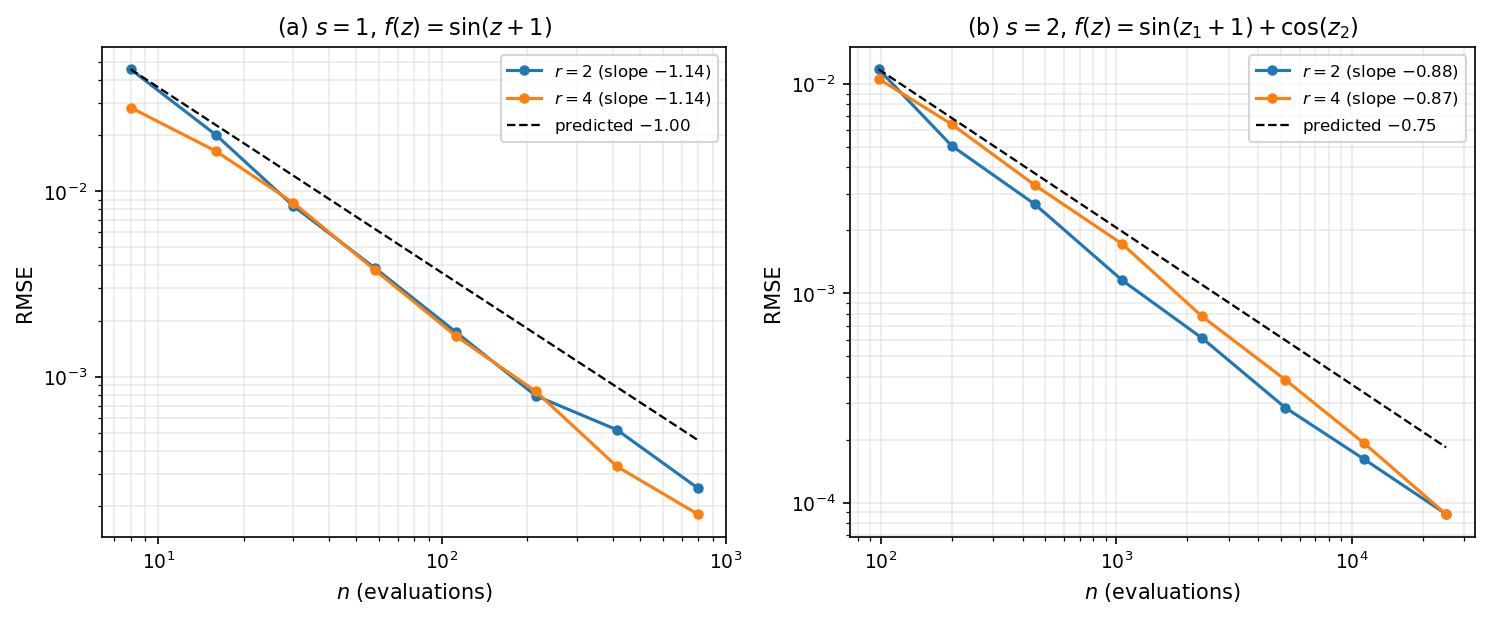

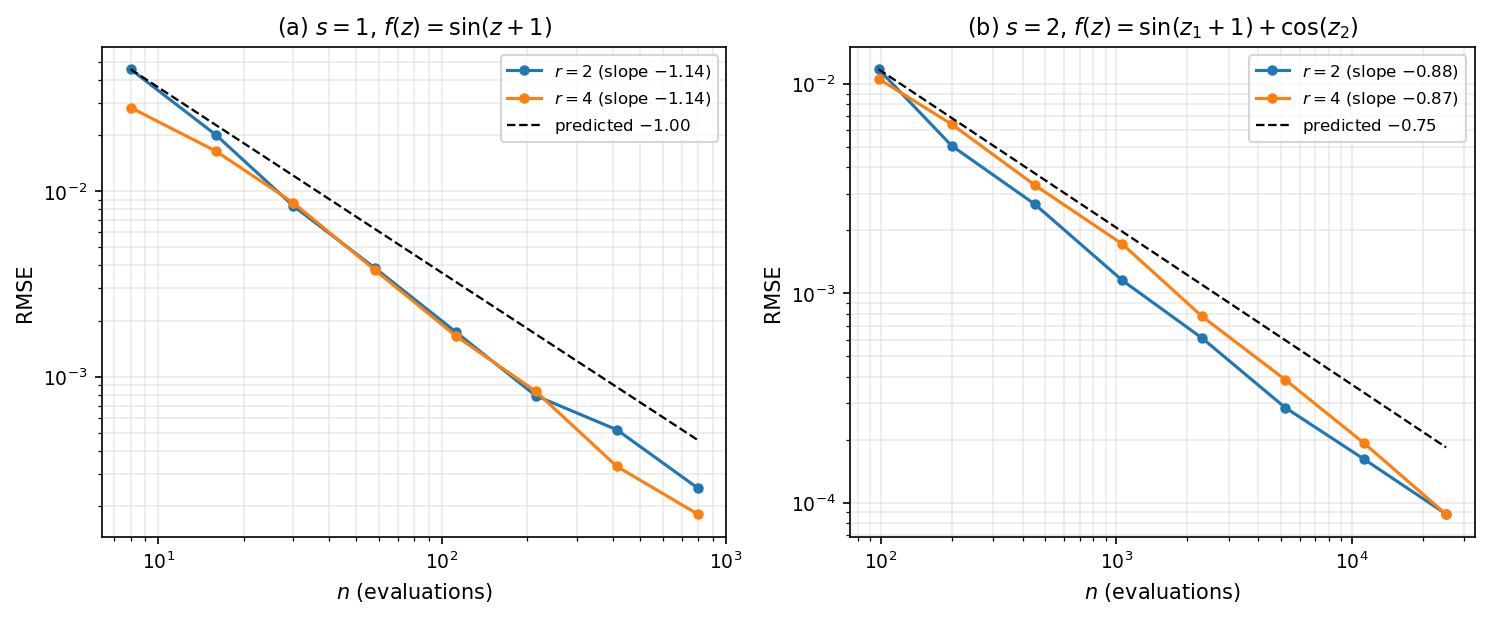

In [10]:
make_figure(nreps=200)